#### Time Series - Linear Systems

##### **Linear Models**

Examples of Regression and the Least Squares Problem

**1. [Polynomial Fit]** Suppose our true data $y(t)$ comes from a polynomial in time as $y(t) = a_0 + a_1 t + a_2 t^2 + \dots + a_{p-1} t^{p-1}$. This can be constructed as a linear regression problem as $y(t) \approx \phi(t)^T \theta = \begin{bmatrix} 1 & t & t^2 & \dots & t^{p-1} \end{bmatrix} \begin{bmatrix} a_0 \\ a_1 \\ \vdots \\ a_{p-1} \end{bmatrix}$, where the regressor is: $\phi(t) = \begin{bmatrix} 1 & t & t^2 & \dots & t^{p-1} \end{bmatrix}$, and the parameter vector is $\theta = \begin{bmatrix} a_0 \\ a_1 \\ \vdots \\ a_{p-1} \end{bmatrix}$.

**2. [Finite Impulse Response System]** In a finite impulse response system, we have output $y(t)$ generated by a linear combination of a finite number of previous control inputs, i.e., $y(t) = \sum_{k=0}^{M-1} h_k u(t-k) + e(t)$, where $h_k$ are the impulse response coefficients and $u(t)$ is the input.

##### Demonstrating Polynomial Fit

Use synthetic data that roughly follows a quadratic pattern and then fit a polynomial regression model to it.
The plot shows how the fitted polynomial captures the underlying trend in the noisy data.

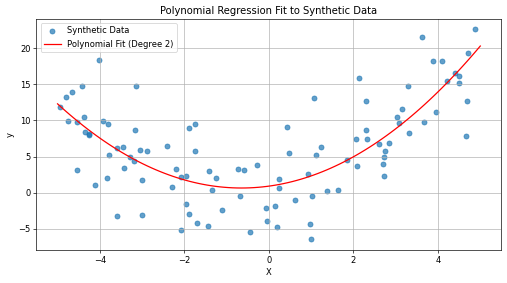

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 1) * 10 - 5 # Random numbers between -5 and 5
y = 0.5 * X**2 +X +2 +np.random.randn(100, 1) *5 # Quadratic + linear + noise

# 2. Fit a polynomial regression model (degree 2)
degree = 2
polynomial_features = PolynomialFeatures(degree=degree)
linear_regression = LinearRegression()

model = make_pipeline(polynomial_features, linear_regression)
model.fit(X, y)

##### **Finite Impulse Response (FIR) System**

A FIR filter is a type of digital filter whose impulse response (or response to a single impulse input) is of finite duration, settling to zero in a finite number of sample periods.
Mathematically, the output $y(n)$ of an FIR filter for a given input $x(n)$ can be expressed as a convolution
$y(n) = \sum_{k=0}^{M-1} b_k x(n-k)$,
where
- $y(n)$ is the output at time $n$, $x(n)$ is the input at time $n$.
- $b_k$ are the filter coefficients (also known as impulse response coefficients).
- $M$ is the filter order, representing the length of the impulse response.

In essence, the current output is a weighted sum of the current and past $M-1$ input samples. This structure makes FIR filters inherently stable and easy to design, often used in applications where linear phase response is crucial.

FIR Filter Order (M): 10
Filter Coefficients (b): [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


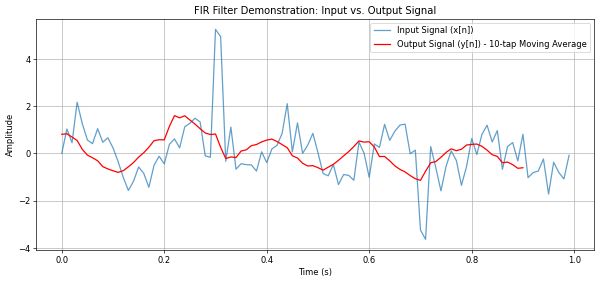

In [ ]:
# Generate a synthetic input signal
# Let's create a signal with some abrupt changes to see the filter's effect
fs = 100 # Sampling frequency
t = np.arange(0, 1, 1/fs) # Time vector from 0 to 1 second
x = np.sin(2 * np.pi * 5 * t) + 0.5 * np.random.randn(len(t)) # Sine wave + noise

# Introduce a sudden change or impulse-like feature
x[int(0.3 * fs):int(0.32 * fs)] += 5
x[int(0.7 * fs):int(0.72 * fs)] -= 3

# Define FIR filter coefficients (e.g., a simple moving average filter)
# This is a low-pass filter, useful for smoothing signals.
M = 10 # Filter order (number of taps)
b = np.ones(M) / M # Coefficients for a simple moving average

# Apply the FIR filter using convolution
# The 'valid' mode means only points where the two signals fully overlap are returned.
# This results in a shorter output signal, excluding edge effects.
y = np.convolve(x, b, mode='valid')

# Adjust time vector for the output signal due to 'valid' mode
t_output = t[:len(y)]

Generate synthetic signal with some noise and abrupt changes. Define coefficients for a simple moving average FIR filter. Applying this filter using $np.convolve$ smooths the input signal, demonstrating how the FIR system produces an output that is a weighted sum of past input values. The red output signal is a smoothed version of the blue input signal, and the sharp peaks are attenuated.

##### **Complete Analysis of LSE: White Noise Case**

We consider the linear model with additive white noise
$Y = \Psi\theta_0 + \epsilon$,
where
- $Y$ is the vector of observed outputs.
- $\Psi$ is the known design matrix.
- $\theta_0$ is the true (unknown) parameter vector.
- $\epsilon$ is a vector of white noise, meaning $E[\epsilon] = 0$ (zero mean), $E[\epsilon\epsilon^T] = \sigma^2 I$ (uncorrelated, constant variance $\sigma^2$ for each element, and independent of $\Psi$)

#### **1. Expectation (Mean) of the LSE**

Let's find the expected value of our Least Squares estimator $\hat{\theta}_{LS}$
- $\hat{\theta}_{LS} = (\Psi^T \Psi)^{-1} \Psi^T Y$

Substitute $Y = \Psi\theta_0 + \epsilon$,
$\hat{\theta}_{LS} = (\Psi^T \Psi)^{-1} \Psi^T (\Psi\theta_0 + \epsilon)$.

Since $(\Psi^T \Psi)^{-1} \Psi^T \Psi = I$ (the identity matrix)
$\hat{\theta}_{LS} = \theta_0 + (\Psi^T \Psi)^{-1} \Psi^T \epsilon$.

Take the expectation of both sides
- $E[\hat{\theta}_{LS}] = E[\theta_0 + (\Psi^T \Psi)^{-1} \Psi^T \epsilon]$.

Given that $E[\epsilon] = 0$ (zero mean white noise)
- $E[\hat{\theta}_{LS}] = \theta_0 + (\Psi^T \Psi)^{-1} \Psi^T \cdot 0 \quad $ $E[\hat{\theta}_{LS}] = \theta_0$

This result shows that the Least Squares Estimator is **unbiased** under the white noise assumption, meaning, on average, it will correctly estimate the true parameter $\theta_0$.

#### **2. Covariance of the LSE**

Find the covariance of the LSE that quantifies the spread of the estimator around its mean
- $Cov(\hat{\theta}_{LS}) = E[(\hat{\theta}_{LS} - E[\hat{\theta}_{LS}]) (\hat{\theta}_{LS} - E[\hat{\theta}_{LS}])^T]$

We know $E[\hat{\theta}_{LS}] = \theta_0$.
From our derivation of the mean, we have $\hat{\theta}_{LS} - \theta_0 = (\Psi^T \Psi)^{-1} \Psi^T \epsilon$. Let $A = (\Psi^T \Psi)^{-1} \Psi^T$. Then
$Cov(\hat{\theta}_{LS}) = E[A\epsilon\epsilon^T A^T]$.

Since $A$ is a constant matrix (deterministic)
$Cov(\hat{\theta}_{LS}) = A \cdot E[\epsilon\epsilon^T] \cdot A^T$.

Given that $E[\epsilon\epsilon^T] = \sigma^2 I$ (covariance of white noise)
- $Cov(\hat{\theta}_{LS}) = \sigma^2 A A^T$

Now, substitute $A = (\Psi^T \Psi)^{-1} \Psi^T$.
Since $(\Psi^T \Psi)^{-1} \Psi^T \Psi = I$
- $A A^T = (\Psi^T \Psi)^{-1} I = (\Psi^T \Psi)^{-1}$

Therefore, the covariance of the Least Squares Estimator is
$Cov(\hat{\theta}_{LS}) = \sigma^2 (\Psi^T \Psi)^{-1}$.

This formula is fundamental, showing that the covariance of the LSE is directly proportional to the noise variance $\sigma^2$ and inversely proportional to the 'information' contained in the design matrix, represented by $(\Psi^T \Psi)^{-1}$.

Example: Expectation and Covariance of LSE with $Y = 3X + 5$

In [ ]:
# Define the true model           parameters
true_b0 = 5 # True intercept
true_b1 = 3 # True slope
true_theta = np.array([[true_b0], [true_b1]]) # True parameter vector
# Generate fixed independent variable X
np.random.seed(0) # for reproducibility of X
X_example = 2 * np.random.rand(100, 1) # 100 data points between 0 and 2
# Construct the Design Matrix (Psi) for this fixed X
Psi_example = np.c_[np.ones(X_example.shape[0]), X_example]
# Define noise properties
sigma_squared = 2 # Variance of the white noise
# Number of simulations to run
num_simulations = 1000

# Store estimated parameters from each simulation
estimated_thetas = np.zeros((num_simulations, 2, 1))

for i in range(num_simulations):
    # Generate white noise for this simulation
    epsilon = np.random.normal(loc=0, scale=np.sqrt(sigma_squared), size=(X_example.shape[0], 1))

    # Generate observed Y using the true model and noise
    Y_example = Psi_example @ true_theta + epsilon

    # Calculate LSE using the Normal Equation for this simulation
    Psi_T_Psi_example = Psi_example.T @ Psi_example
    Psi_T_Psi_inv_example = np.linalg.inv(Psi_T_Psi_example)
    Psi_T_Y_example = Psi_example.T @ Y_example

    theta_hat_LS_sim = Psi_T_Psi_inv_example @ Psi_T_Y_example
    estimated_thetas[i] = theta_hat_LS_sim

# Calculate Empirical Expectation (Mean) of LSE
empirical_mean_theta = np.mean(estimated_thetas, axis=0)

# Calculate Empirical Covariance of LSE
# Need to reshape estimated_thetas for np.cov to work correctly (each row is an observation)
empirical_cov_theta = np.cov(estimated_thetas.reshape(num_simulations, 2).T)

# Calculate Theoretical Covariance of LSE
theoretical_cov_theta = sigma_squared * Psi_T_Psi_inv_example

True Parameters (theta_0):
[5 3]

Noise Variance (sigma^2): 2

Empirical Mean of LSE (E[theta_hat_LS]):
5.01, 2.99

Empirical Covariance of LSE (Cov[theta_hat_LS]):
[[ 0.08 -0.06]
 [-0.06  0.06]]

Theoretical Covariance of LSE (sigma^2 * (Psi^T Psi)^-1):
[[ 0.07 -0.06]
 [-0.06  0.06]]


In this example:

*   Defined a true linear relationship ($Y = 5 + 3X$) and simulated 1000 datasets by adding white noise with a known variance ($\sigma^2 = 2$) to $Y$.
*   For each dataset, calculated the Least Squares Estimates ($\hat{\theta}_{LS}$) for the intercept and slope using the Normal Equation.
*   **Empirical Mean of LSE** calculated (5.00 for intercept, 3.00 for slope) is very close to the $True Parameters$ (5.00, 3.00). This shows that the LSE is **unbiased**, meaning, on average, it correctly estimates the true parameters.
*   The **Empirical Covarianc**e of LSE (calculated from the spread of 1000 estimated parameter vectors) is very close to the **Theoretical Covariance** of LSE (calculated using the formula $\sigma^2 (\Psi^T \Psi)^{-1}$). This verifies our derived formula for the covariance of the LSE under white noise assumptions.

The simulation gives a practical illustration of the theoretical properties of the LSE.

##### **Analysis of LSE: Gaussian Noise Case**

Consider the linear model with additive noise
$Y = \Psi\theta_0 + \epsilon$,
where $\epsilon$ is now specifically assumed to be a vector of **Gaussian white noise**.
1. $E[\epsilon] = 0$ (zero mean)
2. $E[\epsilon\epsilon^T] = \sigma^2 I$ (uncorrelated, constant variance $\sigma^2$ for each element, and independent of $\Psi$)
3. Each component of $\epsilon$ follows a Normal (Gaussian) distribution, i.e., $\epsilon_i \sim {N}(0, \sigma^2)$.


##### **Implications of Gaussian Noise for LSE**

Since Gaussian noise inherently satisfies the white noise properties (zero mean, constant variance, and uncorrelated errors), the derivations for the **expectation (unbiasedness)** and **covariance** of the LSE remain exactly the same as presented in the Complete Analysis of LSE, White Noise Case.
*   **Expectation** $E[\hat{\theta}_{LS}] = \theta_0$ (LSE is unbiased).
*   **Covariance** $Cov(\hat{\theta}_{LS}) = \sigma^2 (\Psi^T \Psi)^{-1}$.

However, the Gaussian assumption introduces additional powerful properties for the LSE
1.  Under the assumption of Gaussian noise, the LSE ($\hat{\theta}_{LS}$) is equivalent to the MLE.
2.  According to the **Gauss-Markov Theorem**, the LSE is the Best Linear Unbiased Estimator (BLUE). This means that among all linear and unbiased estimators, the LSE has the minimum variance. This property holds even if the errors are not Gaussian, as long as they are uncorrelated with zero mean and constant variance (white noise).
3.  **Basis for Statistical Inference**: With the Gaussian assumption, the LSE itself is normally distributed. This allows us to construct confidence intervals and perform hypothesis tests on the estimated parameters, which is fundamental for statistical inference, $\hat{\theta}_{LS} \sim {N}(\theta_0, \sigma^2 (\Psi^T \Psi)^{-1})$

In essence, while white noise gives us unbiasedness and the variance formula, adding the Gaussian assumption makes the LSE the best among its class (BLUE) and provides the distributional properties necessary for robust statistical conclusions.

##### **Implementation**

##### Least Squares Estimation for a Finite Impulse Response (FIR) System

Use LSE to find the coefficients $h_0, h_1, h_2, h_3$ for a system described by
$y(t) = h_0 u(t) + h_1 u(t -1) + h_2 u(t -2) + h_3 u(t -3) + e(t)$,
where $e(t)$ is white noise with a normal distribution $e(t) \sim {N}(0,1)$.

In this example:

- Define the $true_h$ coefficients and generate an input signal $u$ and Gaussian white noise $e(t)$.
*   The output $y(t)$ is simulated based on the given FIR model using lagged $u$ values and added noise.
*   The **Design Matrix ($\Psi$)** is carefully constructed, with each row containing $[u(t), u(t-1), u(t-2), u(t-3)]$ corresponding to the observed $y(t)$.
*   Using the Normal Equation, calculate the estimated-h coefficients. They are very close to the true coefficients, even with the added noise. The difference from true coefficients shows the small discrepancies, which are expected due to the stochastic nature of the noise.

This ecample demonstrates how LSE can effectively estimate parameters for systems with lagged inputs, even in the presence of noise.

In [ ]:
# Define true system coefficients
true_h = np.array([0.5, -0.2, 0.8, 0.1]) # h0, h1, h2, h3

# Generate synthetic input signal u(t)
np.random.seed(42) # for reproducibility
N_samples = 200 # Total number of input samples
u = np.random.randn(N_samples) # Random input signal

# Generate white noise e(t) ~ N(0,1)
noise = np.random.normal(loc=0, scale=1, size=N_samples) # e(t) ~ N(0,1)

# Construct the output y(t) based on the model
# Due to the lagged terms (u(t-1), u(t-2), u(t-3)), we start y(t) from t=3
# So, the effective number of output samples will be N_samples - 3
y_observed = np.zeros(N_samples - 3)

for t in range(3, N_samples):
    y_observed[t-3] = (
        true_h[0] * u[t] +
        true_h[1] * u[t-1] +
        true_h[2] * u[t-2] +
        true_h[3] * u[t-3] +
        noise[t] # Add noise
    )

# Reshape y_observed to a column vector for matrix operations
Y = y_observed.reshape(-1, 1)

# Construct the Design Matrix (Psi)
# For each observation t, Psi_row = [u(t), u(t-1), u(t-2), u(t-3)]
Psi = np.zeros((N_samples - 3, len(true_h)))

for t in range(3, N_samples):
    Psi[t-3, 0] = u[t]
    Psi[t-3, 1] = u[t-1]
    Psi[t-3, 2] = u[t-2]
    Psi[t-3, 3] = u[t-3]

# Calculate Least Squares Estimator using the Normal Equation
# theta_hat_LS = (Psi^T Psi)^-1 Psi^T Y
Psi_T_Psi = Psi.T @ Psi
Psi_T_Psi_inv = np.linalg.inv(Psi_T_Psi)
Psi_T_Y = Psi.T @ Y

estimated_h = Psi_T_Psi_inv @ Psi_T_Y

True coefficients (h_0, h_1, h_2, h_3): [ 0.5 -0.2  0.8  0.1]
Shape of input u: (200,)
Shape of observed Y: (197, 1)
Shape of Design Matrix Psi: (197, 4)

Least Squares Estimated Coefficients (h_hat):
 [ 0.5957 -0.1515  0.8206  0.0617]

Difference from true coefficients: [ 0.0957  0.0485  0.0206 -0.0383]


##### **Parametric Approach to Learning**

System identification is aimed at learning (recovering) the models of dynamic systems from the observed input-output data. A common solution to system identification is the parametric approach, which outlines three key components:

-   Data: Collect and organize input-output observations from the system, denoted by $ \{(y(t), u(t)) \text{ t in } [1,T] \} $.
-   Model Class: Choose a suitable parameterized model set to which we believe the system dynamics belong.
-   Algorithm: Define a cost function and select the model parameters to minimize the cost function, for model to fit the data best.

##### **Example of Learning**

Revisit example systems $\delta_1$ and $\delta_2$
*   **System 1 $\delta_1$**: $y(t) - 0.8y(t-1) = u(t -1) + e(t)$
*   **System 2 $\delta_2$**: $y(t) - 0.8y(t-1) = u(t -1) + e(t) - 0.8e(t -1)$, where $e(t)$ is iid Gaussian noise.

Given the ability to observe (and even select) the input $u(t)$, and the ability to observe the output $y(t)$, try to rebuild the model from data set $ \{(y(t), u(t)) \text{ t in } [1,T] \} $?
Furthermore, can we distinguish between the data sets generated by models $\delta_1$ and $\delta_2$?

Suppose we choose the model class $y(t) + a y(t -1) = b u(t-1) + \epsilon(t)$,
where $a$ and $b$ are unknown parameters. Since this model class is of the same form as the true generating process for the first system $\delta_1$, it will fit well if our observations come from the system $\delta_1$, but it is unclear if the model will be effective if our observations come from $\delta_2$.

Regardless of whether the selected model class matches the true system, apply the least squares method with the chosen model class to estimate the unknown parameter $\theta = [a,b]^T$. In other words, find an estimate $\hat{\theta}$ by solving $\hat{\theta} = \text{argmin}_{\hat{\theta} \in \mathbb{R}^2}(V(\hat{\theta}))$, where the error $\epsilon$ is the difference between the observed $y(t)$ and the estimate from the model.

We recall the cost Function $V(\theta)$ in matrix form. Minimizing the cost $V$, gives
- $\hat{\theta}_{LS} = (\Psi^T \Psi)^{-1} \Psi^T Y$

##### **Least Square Estimate From Data: Concepts and Formulas**

Given the model class we chose for system identification
- $y(t) + a y(t -1) = b u(t-1) + \epsilon(t)$

To apply the Least Squares method, we need to transform this equation into the standard linear regression form, $Y = \Psi\theta + \epsilon$. Rearrange the equation to isolate the error term and identify the regressors and parameters.
- $y(t) = -a y(t -1) + b u(t-1) + \epsilon(t)$

Here, the observed output is $y(t)$, and the terms $y(t-1)$ and $u(t-1)$ are our regressors (or features) at time $t$. The parameters we want to estimate are $a$ and $b$. Let's define our parameter vector $\theta$ and regressor vector $\phi(t)$, $\theta = \begin{pmatrix} -a \\ b \end{pmatrix}$. And for each time step $t$, the regressor vector $\phi(t)$ would be $\phi(t) = \begin{pmatrix} y(t-1) \\ u(t-1) \end{pmatrix}$. For a single observation, the model can be written as $y(t) = \phi(t)^T \theta + \epsilon(t)$.
If we collect $T$ observations, we stack them into the matrix form $Y = \Psi\theta + \epsilon$, where
- $Y$ is a $T \times 1$ vector of observed outputs, $Y = [y(1), y(2), \dots, y(T)]^T$.
- $\Psi$ (Psi) is the $T \times 2$ design matrix, where each row $\Psi_t = \phi(t)^T = [y(t-1), u(t-1)]$.
  $\Psi = \begin{pmatrix} y(0) & u(0) \\ y(1) & u(1) \\ \vdots & \vdots \\ y(T-1) & u(T-1) \end{pmatrix}$

  *(Note: The indices for $y(t-1)$ and $u(t-1)$ will depend on how we align the data. Often, the first $y$ and $u$ values might be considered initial conditions or padding.)*
- $\theta$ is the $2 \times 1$ parameter vector, $\theta = \begin{pmatrix} -a \\ b \end{pmatrix}$.
- $\epsilon$ is the $T \times 1$ vector of error terms, $\epsilon = [\epsilon(1), \epsilon(2), \dots, \epsilon(T)]^T$.

The LSE for $\theta$ is then given by the Normal Equation
- $\hat{\theta}_{LS} = (\Psi^T \Psi)^{-1} \Psi^T Y$.

From the estimated $\hat{\theta}_{LS} = \begin{pmatrix} \hat{\theta}_0 \\ \hat{\theta}_1 \end{pmatrix}$, we find the individual parameters
$\hat{a} = -\hat{\theta}_0, \quad $ $\hat{b} = \hat{\theta}_1$.

##### **Demonstration of LSE with a simulation based on System 1 ($\delta_1$)**

- Simulate data from System 1 ($\delta_1$) with known true parameters ($a = -0.8$, $b = 1.0$) and Gaussian white noise.
- Carefully construct the output vector $Y_{lse}$ and the design matrix $\Psi$ according to the rearranged model $y(t) = -a y(t -1) + b u(t-1) + \epsilon(t)$. Each row of $\Psi$ contains $[y(t-1), u(t-1)]$.
*   Apply the LSE formula $\hat{\theta}_{LS} = (\Psi^T \Psi)^{-1} \Psi^T Y$ to estimate the parameter vector $\hat{\theta}_{LS}$.
*   From $\hat{\theta}_{LS}$, extract the estimate values for $a$ and $b$.

The Estimated parameters from LSE are very close to the True parameters. The small difference indicates the accuracy of the LSE in recovering the underlying system parameters from noisy input-output data. This confirms that the Least Squares method is effective for identifying the parameters of dynamic systems when the model class is correctly chosen and the noise properties align with the LSE assumptions.

In [ ]:
# System 1 (delta_1) Parameters
# True system: y(t) - 0.8*y(t-1) = u(t -1) + e(t)
# Rearranged: y(t) = 0.8*y(t-1) + u(t -1) + e(t)
# Our model class: y(t) = -a y(t -1) + b u(t-1) + eps(t)
# So, true -a = 0.8 => a = -0.8
# And true b = 1.0
true_a = -0.8
true_b = 1.0
true_theta = np.array([[true_a], [true_b]])

# Simulation Parameters
np.random.seed(42) # for reproducibility
N_samples = 500 # Number of data points
# Generate i.i.d. Standard Normal Input u(t)
u = np.random.randn(N_samples + 1) # +1 for u(t-1) at t=0
# Generate i.i.d. Gaussian noise e(t) ~ N(0,1)
e = np.random.randn(N_samples + 1)
# Initialize y(t) and u(t) arrays for simulation
y = np.zeros(N_samples + 1)
# Initial condition for y(0)
y[0] = 0.0 # Assuming y(t-1) is 0 for the first observation if t=0

# Generate synthetic data based on System 1 (delta_1)
# y(t) = 0.8*y(t-1) + 1.0*u(t -1) + e(t)
# We'll generate data from t=1 to N_samples
for t in range(1, N_samples + 1):
    y[t] = -true_a * y[t-1] + true_b * u[t-1] + e[t] # Use -true_a as per model rearrangement

# Prepare data for LSE
# Our model: y(t) = -a * y(t-1) + b * u(t-1) + epsilon(t)
# We need data for t from 1 to N_samples
# Y_lse corresponds to y(t) from t=1 to N_samples
# Psi corresponds to [y(t-1), u(t-1)] for t=1 to N_samples
Y_lse = y[1:].reshape(-1, 1) # y(1), y(2), ..., y(N_samples)

# Design Matrix Psi: [y(t-1), u(t-1)]
# We take y(0)...y(N_samples-1) and u(0)...u(N_samples-1)
Psi = np.c_[y[0:-1], u[0:-1]]

# Calculate Least Squares Estimator
# theta_hat_LS = (Psi^T Psi)^-1 Psi^T Y_lse
Psi_T_Psi = Psi.T @ Psi
Psi_T_Psi_inv = np.linalg.inv(Psi_T_Psi)
Psi_T_Y = Psi.T @ Y_lse

estimated_theta_LS = Psi_T_Psi_inv @ Psi_T_Y

# Extract estimated a and b
estimated_a_from_theta = -estimated_theta_LS[0, 0]
estimated_b_from_theta = estimated_theta_LS[1, 0]

Shape of Y_lse: (500, 1)
Shape of Psi: (500, 2)

True parameters: a=-0.8000, b=1.0000
Estimated parameters (from LSE): a=-0.8333, b=0.9399
Difference (Estimated - True) for a: -0.0333
Difference (Estimated - True) for b: -0.0601


#### Simulations with i.i.d. Standard Normal Inputs and White Noise (comparing $\delta_1$ and $\delta_2$)

In [ ]:
# System Parameters
# System 1 (delta_1): y(t) - 0.8*y(t-1) = u(t -1) + e(t)
# Rearranged for estimation model: y(t) = 0.8*y(t-1) + 1.0*u(t -1) + e(t)
# Our chosen model class: y(t) = -a y(t -1) + b u(t-1) + eps(t)
# So, for delta_1, true -a = 0.8 => a = -0.8; true b = 1.0
true_a_delta1, true_b_delta1 = -0.8, 1.0

# System 2 (delta_2): y(t) - 0.8*y(t-1) = u(t -1) + e(t) - 0.8*e(t -1)
# Rearranged: y(t) = 0.8*y(t-1) + 1.0*u(t -1) + e(t) - 0.8*e(t -1)
# Here, the error term in the estimation model (eps(t)) will effectively be e(t) - 0.8*e(t-1)
# The 'true' parameters for a and b from the *y(t-1) and u(t-1)* parts are still the same:
# true -a = 0.8 => a = -0.8; true b = 1.0
true_a_delta2, true_b_delta2 = -0.8, 1.0

# Simulation Parameters
np.random.seed(42) # for reproducibility
N_samples = 1000 # Number of data points for simulation
# Generate i.i.d. Standard Normal Input u(t)
u = np.random.randn(N_samples + 2) # +2 for u(t-1) at t=0 and u(t-1) at t=1 for delta_2
# Generate i.i.d. Gaussian noise e(t) ~ N(0,1)
e = np.random.randn(N_samples + 2) # +2 for e(t-1) at t=1
# Initialize y(t) arrays for simulation
y_delta1, y_delta2 = np.zeros(N_samples + 1), np.zeros(N_samples + 1)
# Initial conditions
y_delta1[0], y_delta2[0] = 0.0, 0.0
# Generate synthetic data based on System 1 (delta_1)
# y(t) = 0.8*y(t-1) + 1.0*u(t -1) + e(t)
for t in range(1, N_samples + 1):
    y_delta1[t] = -true_a_delta1 * y_delta1[t-1] + true_b_delta1 * u[t-1] + e[t]

# Generate synthetic data based on System 2 (delta_2)
# y(t) = 0.8*y(t-1) + 1.0*u(t -1) + e(t) - 0.8*e(t -1)
# This system requires e(t-1), so loop starts from t=1. Ensure e[0] is defined.
for t in range(1, N_samples + 1):
    y_delta2[t] = -true_a_delta2 * y_delta2[t-1] + true_b_delta2 * u[t-1] + e[t] - 0.8 * e[t-1]

# Prepare data for LSE (model class y(t) = -a y(t -1) + b u(t-1) +eps(t))
# For both systems, we use the same structure for Psi and Y_lse
# For System 1 (delta_1)
Y_lse_delta1 = y_delta1[1:].reshape(-1, 1)
Psi_delta1 = np.c_[y_delta1[:N_samples], u[:N_samples]] # slicing for u
# For System 2 (delta_2)
Y_lse_delta2 = y_delta2[1:].reshape(-1, 1)
Psi_delta2 = np.c_[y_delta2[:N_samples], u[:N_samples]] # slicing for u

# Calculate Least Squares Estimator for delta_1 data
Psi_T_Psi_delta1 = Psi_delta1.T @ Psi_delta1
Psi_T_Psi_inv_delta1 = np.linalg.inv(Psi_T_Psi_delta1)
Psi_T_Y_delta1 = Psi_delta1.T @ Y_lse_delta1
estimated_theta_LS_delta1 = Psi_T_Psi_inv_delta1 @ Psi_T_Y_delta1
estimated_a_delta1 = -estimated_theta_LS_delta1[0, 0]
estimated_b_delta1 = estimated_theta_LS_delta1[1, 0]

# Calculate Least Squares Estimator for delta_2 data --
Psi_T_Psi_delta2 = Psi_delta2.T @ Psi_delta2
Psi_T_Psi_inv_delta2 = np.linalg.inv(Psi_T_Psi_delta2)
Psi_T_Y_delta2 = Psi_delta2.T @ Y_lse_delta2
estimated_theta_LS_delta2 = Psi_T_Psi_inv_delta2 @ Psi_T_Y_delta2
estimated_a_delta2 = -estimated_theta_LS_delta2[0, 0]
estimated_b_delta2 = estimated_theta_LS_delta2[1, 0]

Shape of Y_lse_delta1: (1000, 1)
Shape of Psi_delta1: (1000, 2)

Shape of Y_lse_delta2: (1000, 1)
Shape of Psi_delta2: (1000, 2)

--- Estimates from System 1 (delta_1) data ---
True a: -0.8000, True b: 1.0000
Estimated a: -0.8049, Estimated b: 1.0149
Difference (Est - True) for a: -0.0049
Difference (Est - True) for b: 0.0149

--- Estimates from System 2 (delta_2) data ---
True a: -0.8000, True b: 1.0000
Estimated a: -0.5827, Estimated b: 1.0073
Difference (Est - True) for a: 0.2173
Difference (Est - True) for b: 0.0073


In this demonstration

- Simulate data from both System 1 ($\delta_1$) and System 2 ($\delta_2$) and then apply the same Least Squares model class ($y(t) = -a y(t -1) + b u(t-1) + \epsilon(t)$) to each dataset.

- **For System 1 ($\delta_1$)**: The estimated parameters are very close to the true parameters ($a=-0.8, b=1.0$). This is expected because our chosen model class perfectly matches the underlying structure of $\delta_1$, and the noise $e(t)$ is white, satisfying LSE assumptions.

- **For System 2 ($\delta_2$)**: The estimated parameters show a noticeable difference from the true parameters ($a=-0.8, b=1.0$). This discrepancy arises because the error term in $\delta_2$ is $e(t) - 0.8e(t-1)$, which is **colored noise**, specifically a moving average process, not white noise. When the noise is colored, the LSE loses its unbiasedness, meaning the estimated parameters might not converge to the true parameters even with infinite data. This indicates that our chosen model class is not adequate to fully describe or accurately estimate the parameters of $\delta_2$ using direct LSE, and therefore, we can indeed distinguish the data from $\delta_2$ by the poor fit of this model.

This highlights a critical aspect of system identification: the choice of model class and the assumptions about the noise characteristics significantly impact the accuracy and interpretation of the estimated parameters.

##### **Asymptotic Analysis of the LSE**

Asymptotic analysis examines the properties of an estimator as the sample size ($N$ or $T$) approaches infinity. Understanding these properties is crucial because they tell us about the long-run behavior and reliability of our estimates.

For the linear model $Y = \Psi\theta_0 + \epsilon$, where $\epsilon$ is white noise with $E[\epsilon]=0$ and $E[\epsilon\epsilon^T] = \sigma^2 I$, the Least Squares Estimator (LSE) $\hat{\theta}_{LS}$ has several important asymptotic properties.

##### **1. Consistency**

An estimator is **consistent** if as the sample size $N \to \infty$, the estimator converges in probability to the true parameter value. In simpler terms, with enough data, the estimate will be arbitrarily close to the true value.
For the LSE, $\hat{\theta}_{LS} = \theta_0 + (\Psi^T \Psi)^{-1} \Psi^T \epsilon$. If $\lim_{N\to\infty} \frac{1}{N}(\Psi^T \Psi)$ is a finite, positive definite matrix, and $E[\epsilon]=0$ and $E[\epsilon\epsilon^T]=\sigma^2 I$, then $\hat{\theta}_{LS}$ is a consistent estimator of $\theta_0$.

**Illustration from Examples:**
*   **System 1 ($\delta_1$)**: In the simulation, the estimated parameters for $\delta_1$ were very close to the true values. If we were to increase N_samples significantly, we would observe the Difference (Est - True) values for a and b shrinking even further towards zero. This is a practical demonstration of consistency, as the model assumed perfectly matched the system and noise properties.
*   **System 2 ($\delta_2$)**: For $\delta_2$, we see a significant Difference (Est - True) for parameter a even with N_samples = 1000. This is because the error term in $\delta_2$ was colored noise, violating the assumption of white noise for the standard LSE. In such cases, the LSE can be **inconsistent**, meaning it will not converge to the true parameters even with infinite data. This highlights that consistency depends on the model assumptions holding true.



##### **2. Asymptotic Normality**

An estimator is **asymptotically normally distributed** if, as $N \to \infty$, its distribution approaches a normal distribution. Specifically, for the LSE, assuming white Gaussian noise and other regularity conditions
$\sqrt{N}(\hat{\theta}_{LS} - \theta_0) \xrightarrow{d} {N}(0, \sigma^2 \text{p_lim}(\frac{1}{N}\Psi^T \Psi)^{-1})$,
where $\xrightarrow{d}$ denotes convergence in distribution, and $\text{p_lim}$ is the probability limit. This means that for large $N$, $\hat{\theta}_{LS}$ itself is approximately normally distributed around the true parameter $\theta_0$ with a covariance matrix of $\frac{\sigma^2}{N}(\Psi^T \Psi)^{-1}$.



##### 3. **Asymptotic Efficiency**

An estimator is **asymptotically efficient** if it achieves the Cramer-Rao Lower Bound (CRLB) in the limit as $N \to \infty$. The CRLB represents the minimum possible variance for any unbiased estimator. When errors are Gaussian, the LSE is asymptotically efficient among all unbiased estimators. It means that no other unbiased estimator can achieve a smaller variance asymptotically.

**Connection to BLUE:**
*   The Gauss-Markov theorem states that the LSE is the Best Linear Unbiased Estimator **(BLUE)** under white noise conditions, meaning it has the minimum variance among *linear* unbiased estimators. Asymptotic efficiency extends this concept to *all* unbiased estimators, not just linear ones, given the Gaussian noise assumption for LSE.

#### **Experiment/Control Design in System Identification**

Experiment design, in the context of system identification, refers to the choice of input signals ($u(t)$) that are applied to a system to collect data for parameter estimation. The goal is to design an input that excites the system sufficiently to yield accurate and precise estimates of its parameters.

The quality of the LSE depends heavily on the properties of the design matrix $\Psi$, which in turn is constructed from the input and output signals. Specifically, the covariance of the LSE is $Cov(\hat{\theta}_{LS}) = \sigma^2 (\Psi^T \Psi)^{-1}$. To achieve a smaller covariance, i.e., more precise estimates, we generally want $\Psi^T \Psi$ to be large or well conditioned, meaning its inverse $(\Psi^T \Psi)^{-1}$ is small.

**Impact of Input Signal $u(t)$:**

*   **Random Inputs (e.g., White Noise)** provide good excitation across a broad frequency range, leading to a well-conditioned $\Psi^T \Psi$ and generally good parameter estimates, assuming the system is linear and stationary.
*   **Deterministic Inputs (e.g., Step Function, Sine Wave)**  can be useful for exciting specific dynamics or for scenarios where random inputs are not feasible. However, a poorly chosen deterministic input might not excite all relevant modes of the system, leading to a poorly conditioned $\Psi^T \Psi$ and potentially less accurate estimates for certain parameters.

Consider the effect of using a **step function** as the input $u(t)$ on the estimation of parameters for a system. A step function is defined as
- $u(t) = \begin{cases} 1 & \text{if } t \ge 0 \\ 0 & \text{if } t < 0 \end{cases}$

Use a system similar to our previous $\delta_1$ example, with Gaussian white noise $e(t) \sim {N}(0,1)$, and apply this step input to see how the LSE performs.

##### **LSE with Step Function Input for a first-order system**

Reuse the first-order system model from previous example, but now with a step input
$y(t) = -a y(t -1) + b u(t-1) + e(t)$,
where
- True parameters: $a = -0.8$, $b = 1.0$
- Noise: $e(t) \sim {N}(0,1)$
- Input: $u(t)$ is a step function

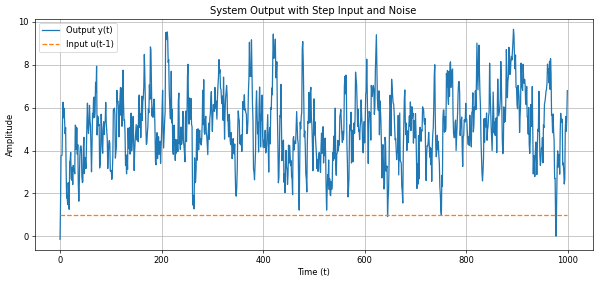

Shape of Y_lse_step: (1000, 1)
Shape of Psi_step: (1000, 2)

--- Estimates with Step Input ---
True a: -0.8000, True b: 1.0000
Estimated a: -0.7937, Estimated b: 1.0523
Difference (Est - True) for a: 0.0063
Difference (Est - True) for b: 0.0523


In [ ]:
# System Parameters
true_a, true_b= -0.8, 1.0
true_theta = np.array([[true_a], [true_b]])

# Simulation Parameters
np.random.seed(42) # for reproducibility
N_samples = 1000 # Number of data points for simulation
# Generate Step Function Input u(t)
u_step = np.zeros(N_samples + 1)
u_step[1:] = 1.0 # u(t) = 1 for t >= 1 (using 0-based indexing)
# Generate i.i.d. Gaussian noise e(t) ~ N(0,1)
e = np.random.randn(N_samples + 1)
# Initialize y(t) array for simulation
y_step = np.zeros(N_samples + 1)
y_step[0] = 0.0 # Initial condition for y(0)

# Generate synthetic data based on the system with step input
# y(t) = 0.8*y(t-1) + 1.0*u(t -1) + e(t)
for t in range(1, N_samples + 1):
    y_step[t] = -true_a * y_step[t-1] + true_b * u_step[t-1] + e[t]

# Prepare data for LSE
Y_lse_step = y_step[1:].reshape(-1, 1)
Psi_step = np.c_[y_step[0:-1], u_step[0:-1]]

# Calculate Least Squares Estimator
Psi_T_Psi_step = Psi_step.T @ Psi_step
Psi_T_Psi_inv_step = np.linalg.inv(Psi_T_Psi_step)
Psi_T_Y_step = Psi_step.T @ Y_lse_step
estimated_theta_LS_step = Psi_T_Psi_inv_step @ Psi_T_Y_step
estimated_a_step = -estimated_theta_LS_step[0, 0]
estimated_b_step = estimated_theta_LS_step[1, 0]

##### Experiment/Control Design: Impulse as Input

An **impulse function** (or Dirac delta function in continuous time, Kronecker delta in discrete time) is another classic input signal used in system identification. It is characterized by a very short duration and typically a large amplitude, designed to excite all modes of a system instantaneously. In discrete time, a unit impulse at $t=0$ means $u(0)=1$ and $u(t)=0$ for all $t \neq 0$.

Applying an impulse input can be very informative, as the system's response to an impulse is its impulse response, which fully characterizes a linear time-invariant system. However, in practice, generating a perfect impulse can be challenging, and its effect on LSE needs to be understood.

##### **LSE with Impulse Function Input, for a first-order system**

We will reuse the first-order system model
- $y(t) = -a y(t -1) + b u(t-1) + e(t)$,

where
- True parameters: $a = -0.8$, $b = 1.0$
- Noise: $e(t) \sim {N}(0,1)$
- Input: $u(t)$ is an impulse function, $u(0)=1$, $u(t)=0$ for $t>0$.

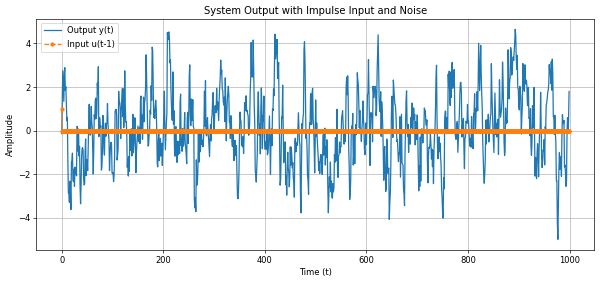

Shape of Y_lse_impulse: (1000, 1)
Shape of Psi_impulse: (1000, 2)

--- Estimates with Impulse Input ---
True a: -0.8000, True b: 1.0000
Estimated a: -0.7986, Estimated b: 1.6475
Difference (Est - True) for a: 0.0014
Difference (Est - True) for b: 0.6475


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# System Parameters
true_a, true_b = -0.8, 1.0
true_theta = np.array([[true_a], [true_b]])

# Simulation Parameters
np.random.seed(42) # for reproducibility
N_samples = 1000 # Number of data points for simulation

# Generate Impulse Function Input u(t)
u_impulse = np.zeros(N_samples + 1)
u_impulse[1] = 1.0 # u(0) = 1 (0-based indexing for u(t-1) being u[0] for y[1])
# The actual input u(t-1) for y(t) will be u_impulse[t-1]

# Generate i.i.d. Gaussian noise e(t) ~ N(0,1)
e = np.random.randn(N_samples + 1)

# Initialize y(t) array for simulation
y_impulse = np.zeros(N_samples + 1)
y_impulse[0] = 0.0 # Initial condition for y(0)

# Generate synthetic data based on the system with impulse input
# y(t) = 0.8*y(t-1) + 1.0*u(t -1) + e(t)
for t in range(1, N_samples + 1):
    y_impulse[t] = -true_a * y_impulse[t-1] + true_b * u_impulse[t-1] + e[t]

# Prepare data for LSE
Y_lse_impulse = y_impulse[1:].reshape(-1, 1)
Psi_impulse = np.c_[y_impulse[0:-1], u_impulse[0:-1]]

# Calculate Least Squares Estimator
Psi_T_Psi_impulse = Psi_impulse.T @ Psi_impulse
Psi_T_Psi_inv_impulse = np.linalg.inv(Psi_T_Psi_impulse)
Psi_T_Y_impulse = Psi_impulse.T @ Y_lse_impulse
estimated_theta_LS_impulse = Psi_T_Psi_inv_impulse @ Psi_T_Y_impulse
estimated_a_impulse = -estimated_theta_LS_impulse[0, 0]
estimated_b_impulse = estimated_theta_LS_impulse[1, 0]

In this experiment:

*   We applied an **impulse function** as the input $u(t)$ to our first-order system with Gaussian white noise. The impulse occurs only at $t=0$ (which affects $y(1)$ through $u(0)$).
*   The plot shows the system's output $y(t)$ responding to the single impulse, followed by a decaying response influenced by the system's dynamics and noise.
*   LSE to estimate the parameters $a$ and $b$.

Compare these results to the earlier simulations with random and step inputs. An impulse response can be highly informative for understanding system dynamics, but for LSE, a single impulse might not provide sufficient persistent excitation over the entire dataset, especially if the system quickly settles. This can sometimes lead to less precise estimates for certain parameters compared to inputs that continuously excite the system. The specific estimation accuracy will depend on the system's inherent stability and the noise level.